# WCS 06 — Product/Source Coverage Across the Detector

**Purpose:** Compare where different astrometry.net source sets live on the detector.

**Main question:** Does the right side of the image have many detected sources that were simply not used in `corr.fits`, or does the right side genuinely lack usable detections and reference stars?

**Inputs (from `out/wcs_diagnostics/products/` — no re-submission needed):**
- `axy.fits` — sources submitted to and accepted by astrometry.net
- `corr.fits` — correspondence matches used internally for the solve (sparse subset)
- `rdls.fits` — reference/catalog stars in the solved field
- `image-radec.fits` — all detected sources projected to RA/Dec by the solved WCS

`corr.fits` is astrometry.net's *internal* correspondence table, not a completeness-limited match catalog.

In [1]:
import sys
from pathlib import Path
import warnings
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.table import Table

OUT_DIR  = ROOT / 'out' / 'wcs_diagnostics'
PROD_DIR = OUT_DIR / 'products'
CACHE    = OUT_DIR / 'platesolve_result.pkl'

if not CACHE.exists():
    raise FileNotFoundError(f'Run wcs_01 first to create {CACHE}')
with open(CACHE, 'rb') as f:
    result = pickle.load(f)

with afits.open(sorted((ROOT / 'data').glob('*.fit'))[0]) as hdul:
    image = hdul[0].data.astype(float)
h, w = image.shape

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

cd11 = result.header.get('CD1_1', 0)
cd21 = result.header.get('CD2_1', 0)
plate_scale = np.hypot(cd11, cd21) * 3600  # arcsec/px

print(f'Image        : {w} x {h} px')
print(f'Plate scale  : {plate_scale:.1f} arcsec/px')
print(f'Products dir : {PROD_DIR}')

Image        : 3096 x 2080 px
Plate scale  : 80.9 arcsec/px
Products dir : C:\Users\bassd\Research\Spectra Angle\spectrangle\out\wcs_diagnostics\products


In [2]:
def _load_fits_table(path, label):
    p = Path(path)
    if not p.exists():
        print(f'  {label}: NOT FOUND at {p.name}')
        return None
    with afits.open(p) as hdul:
        tbl_hdu = next(
            (h for h in hdul if isinstance(h, (afits.BinTableHDU, afits.TableHDU))), None
        )
        if tbl_hdu is None:
            print(f'  {label}: no table HDU')
            return None
        t = Table(tbl_hdu.data)
    print(f'  {label}: {len(t)} rows | cols: {t.colnames}')
    return t

def _fallback(tbl, attr):
    if tbl is not None:
        return tbl
    t = getattr(result, attr, None)
    if t is not None:
        print(f'  {attr}: using in-memory fallback ({len(t)} rows)')
    return t

print('Loading product tables from disk:')
axy_tbl   = _load_fits_table(PROD_DIR / 'axy.fits',         'axy      ')
corr_tbl  = _load_fits_table(PROD_DIR / 'corr.fits',        'corr     ')
rdls_tbl  = _load_fits_table(PROD_DIR / 'rdls.fits',        'rdls     ')
imgrd_tbl = _load_fits_table(PROD_DIR / 'image-radec.fits', 'image_rd ')

axy_tbl   = _fallback(axy_tbl,   'axy_table')
corr_tbl  = _fallback(corr_tbl,  'corr_table')
rdls_tbl  = _fallback(rdls_tbl,  'rdls_table')
imgrd_tbl = _fallback(imgrd_tbl, 'image_radec_table')

Loading product tables from disk:
  axy      : 255 rows | cols: ['X', 'Y']
  corr     : 48 rows | cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  rdls     : 179 rows | cols: ['MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG', 'RA', 'DEC']
  image_rd : 255 rows | cols: ['ra', 'dec', 'x', 'y']


In [3]:
def gcol(tbl, *names):
    """Case-insensitive column getter. Returns float ndarray or None."""
    if tbl is None:
        return None
    lower = {c.strip().lower(): c for c in tbl.colnames}
    for n in names:
        key = lower.get(n.strip().lower())
        if key is not None:
            return np.asarray(tbl[key], dtype=float)
    return None

axy_x    = gcol(axy_tbl,   'X')
axy_y    = gcol(axy_tbl,   'Y')
corr_fx  = gcol(corr_tbl,  'field_x')
corr_fy  = gcol(corr_tbl,  'field_y')
rdls_ra  = gcol(rdls_tbl,  'RA')
rdls_dec = gcol(rdls_tbl,  'DEC')
imgrd_x  = gcol(imgrd_tbl, 'x')
imgrd_y  = gcol(imgrd_tbl, 'y')

print('Column extraction:')
for name, a in [('axy x/y', axy_x), ('corr fx/fy', corr_fx),
                ('rdls RA/DEC', rdls_ra), ('imgrd x/y', imgrd_x)]:
    print(f'  {name:16s}: {len(a) if a is not None else "MISSING"}')

Column extraction:
  axy x/y         : 255
  corr fx/fy      : 48
  rdls RA/DEC     : 179
  imgrd x/y       : 255


In [4]:
rdls_px = rdls_py = np.array([])
rdls_mag = None
_rdls_mag_col = None

if rdls_ra is not None and rdls_dec is not None:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _px_all, _py_all = wcs.world_to_pixel_values(rdls_ra, rdls_dec)

    margin = 50
    in_frame = (
        (_px_all >= -margin) & (_px_all < w + margin) &
        (_py_all >= -margin) & (_py_all < h + margin)
    )
    rdls_px = _px_all[in_frame]
    rdls_py = _py_all[in_frame]
    print(f'rdls projected: {len(rdls_px)} / {len(rdls_ra)} stars within image bounds')
    print(f'  x range: [{rdls_px.min():.0f}, {rdls_px.max():.0f}]')
    print(f'  y range: [{rdls_py.min():.0f}, {rdls_py.max():.0f}]')

    for col in ['MAG_HP', 'MAG_VT', 'MAG_BT', 'MAG']:
        v = gcol(rdls_tbl, col)
        if v is not None:
            rdls_mag = v[in_frame]
            _rdls_mag_col = col
            print(f'  mag ({col}): {np.nanmin(rdls_mag):.1f} - {np.nanmax(rdls_mag):.1f}')
            break
else:
    print('rdls projection skipped (no RA/Dec columns)')

rdls projected: 179 / 179 stars within image bounds
  x range: [11, 3099]
  y range: [26, 2055]
  mag (MAG_HP): 0.0 - 3.0


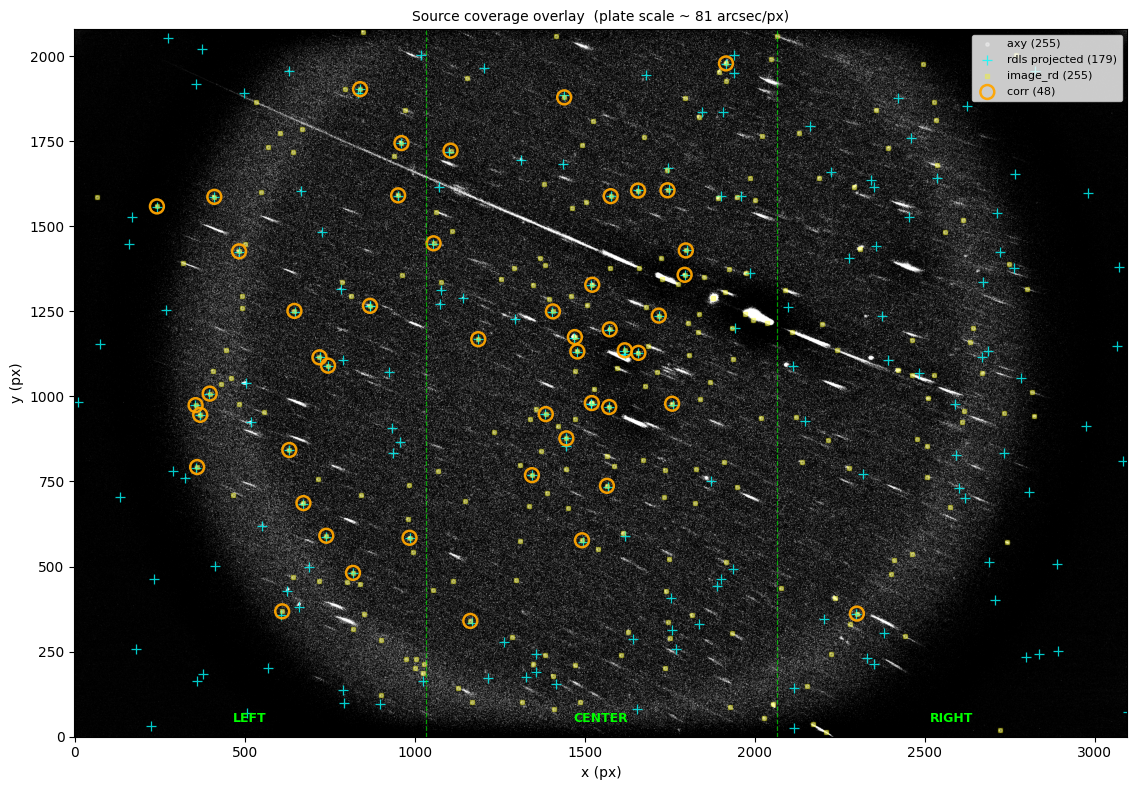

Saved wcs06_coverage_overlay.png


In [5]:
bg   = gaussian_filter(image.astype(np.float32), sigma=50.0)
proc = np.clip(image.astype(np.float32) - bg, 0.0, None)
lo, hi = np.percentile(proc[np.isfinite(proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(proc, lo, hi))

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor('#111')
ax.imshow(disp, origin='lower', cmap='gray',
          vmin=np.arcsinh(lo), vmax=np.arcsinh(hi), aspect='equal')

if axy_x is not None:
    ax.scatter(axy_x, axy_y, s=6, c='white', alpha=0.35,
               label=f'axy ({len(axy_x)})')
if len(rdls_px) > 0:
    ax.scatter(rdls_px, rdls_py, s=50, marker='+', c='cyan', linewidths=0.9,
               alpha=0.8, label=f'rdls projected ({len(rdls_px)})')
if imgrd_x is not None:
    ax.scatter(imgrd_x, imgrd_y, s=12, c='yellow', alpha=0.3, marker='s',
               label=f'image_rd ({len(imgrd_x)})')
if corr_fx is not None:
    ax.scatter(corr_fx, corr_fy, s=100, facecolors='none', edgecolors='orange',
               linewidths=1.8, alpha=0.95, label=f'corr ({len(corr_fx)})')

for xv in [w/3, 2*w/3]:
    ax.axvline(xv, color='lime', lw=0.9, linestyle='--', alpha=0.6)
for xv, lbl in [(w/6, 'LEFT'), (w/2, 'CENTER'), (5*w/6, 'RIGHT')]:
    ax.text(xv, h * 0.02, lbl, color='lime', ha='center', fontsize=9, fontweight='bold')

ax.set_xlim(-0.5, w - 0.5)
ax.set_ylim(-0.5, h - 0.5)
ax.set_xlabel('x (px)')
ax.set_ylabel('y (px)')
ax.set_title(f'Source coverage overlay  (plate scale ~ {plate_scale:.0f} arcsec/px)', fontsize=10)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs06_coverage_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs06_coverage_overlay.png')

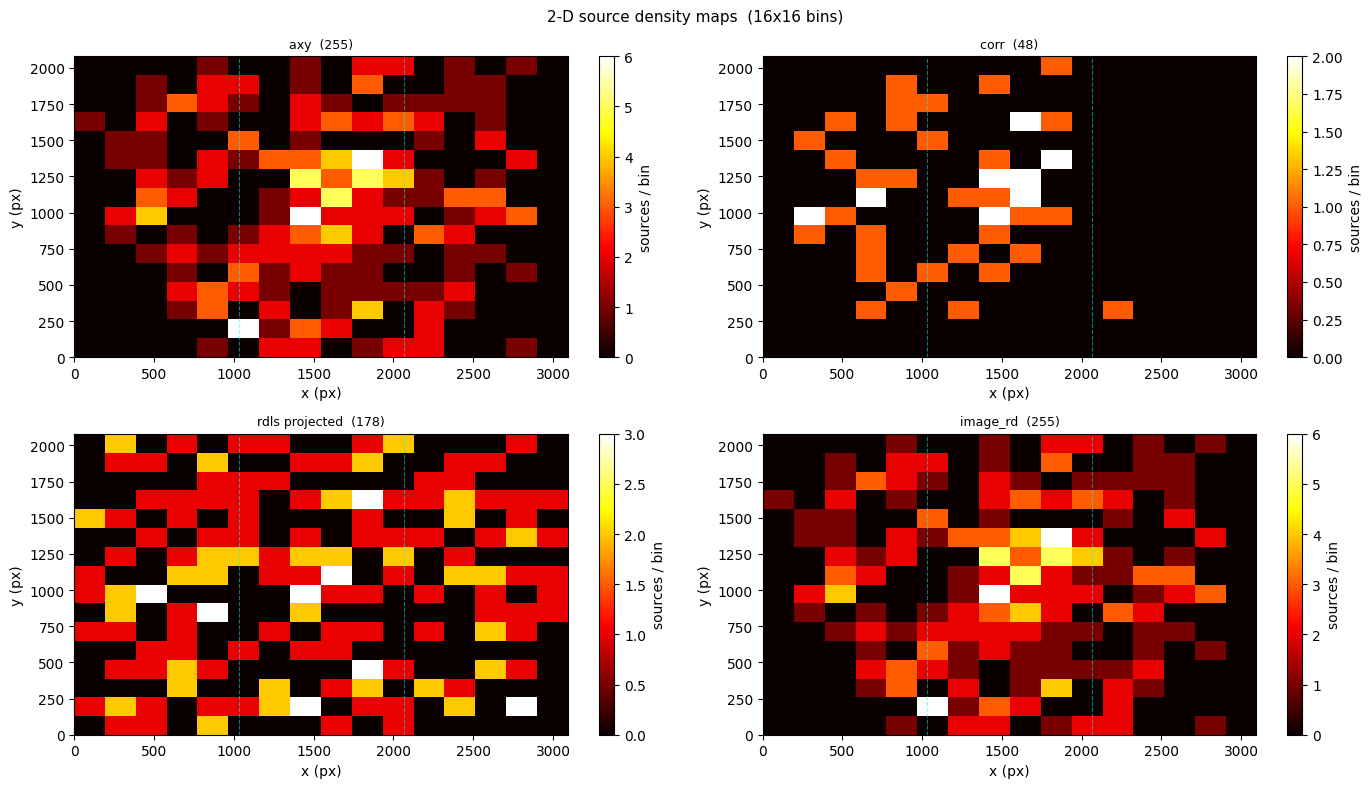

Saved wcs06_density_maps.png


In [6]:
_nb = 16
_xe = np.linspace(0, w, _nb + 1)
_ye = np.linspace(0, h, _nb + 1)

def _h2d(x, y):
    if x is None or len(x) == 0:
        return np.zeros((_nb, _nb))
    H, _, _ = np.histogram2d(x, y, bins=[_xe, _ye])
    return H.T

_rdls_x = rdls_px if len(rdls_px) > 0 else None
_rdls_y = rdls_py if len(rdls_py) > 0 else None

Hs = [_h2d(axy_x, axy_y),
      _h2d(corr_fx, corr_fy),
      _h2d(_rdls_x, _rdls_y),
      _h2d(imgrd_x, imgrd_y)]
titles = [f'axy  ({int(Hs[0].sum())})',
          f'corr  ({int(Hs[1].sum())})',
          f'rdls projected  ({int(Hs[2].sum())})',
          f'image_rd  ({int(Hs[3].sum())})']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, H, title in zip(axes.flat, Hs, titles):
    ax.set_facecolor('#111')
    im = ax.imshow(H, origin='lower', extent=[0, w, 0, h],
                   cmap='hot', aspect='auto', vmin=0, vmax=max(H.max(), 1))
    plt.colorbar(im, ax=ax, label='sources / bin')
    for xv in [w/3, 2*w/3]:
        ax.axvline(xv, color='cyan', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')

fig.suptitle(f'2-D source density maps  ({_nb}x{_nb} bins)', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs06_density_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs06_density_maps.png')

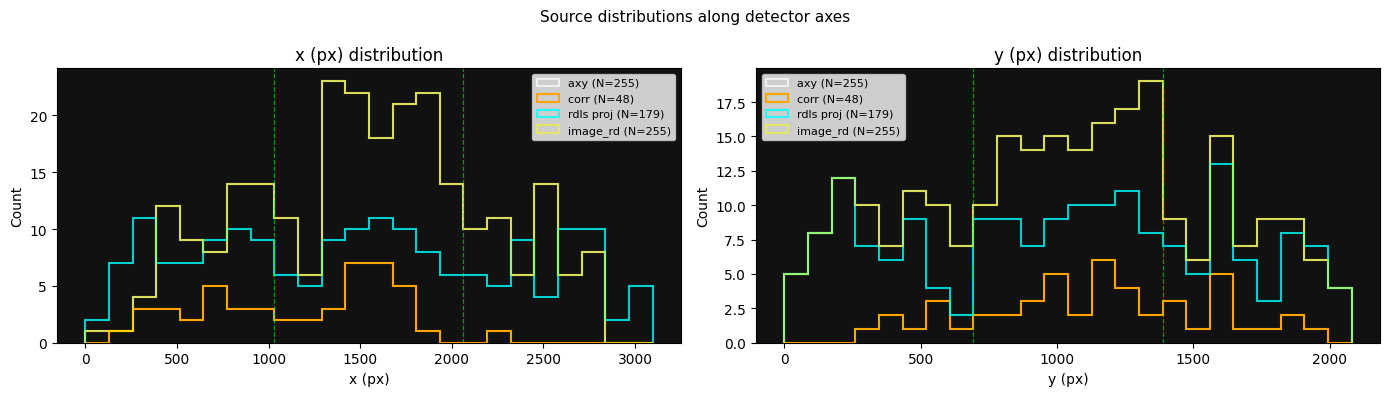

Saved wcs06_xy_histograms.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
_bins_x = np.linspace(0, w, 25)
_bins_y = np.linspace(0, h, 25)

_rdls_px_s = rdls_px if len(rdls_px) > 0 else None
_rdls_py_s = rdls_py if len(rdls_py) > 0 else None
_srcs = [
    ('axy',       axy_x,    axy_y,    'white',  0.7),
    ('corr',      corr_fx,  corr_fy,  'orange', 1.0),
    ('rdls proj', _rdls_px_s, _rdls_py_s, 'cyan', 0.8),
    ('image_rd',  imgrd_x,  imgrd_y,  'yellow', 0.5),
]

for ax, col_idx, bins, xlabel, divs in [
    (axes[0], 0, _bins_x, 'x (px)', [w/3, 2*w/3]),
    (axes[1], 1, _bins_y, 'y (px)', [h/3, 2*h/3]),
]:
    ax.set_facecolor('#111')
    for lbl, xs, ys, col, alp in _srcs:
        data = [xs, ys][col_idx]
        if data is not None and len(data) > 0:
            ax.hist(data, bins=bins, color=col, alpha=alp,
                    histtype='step', linewidth=1.5, label=f'{lbl} (N={len(data)})')
    for xv in divs:
        ax.axvline(xv, color='lime', lw=0.9, linestyle='--', alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.set_title(f'{xlabel} distribution')

fig.suptitle('Source distributions along detector axes', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs06_xy_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved wcs06_xy_histograms.png')

In [8]:
regions = [
    ('LEFT',   0,         w // 3),
    ('CENTER', w // 3,    2 * w // 3),
    ('RIGHT',  2*w // 3,  w),
]

def _n(arr, x0, x1):
    if arr is None or len(arr) == 0:
        return 0
    return int(np.sum((arr >= x0) & (arr < x1)))

_rdls_x = rdls_px if len(rdls_px) > 0 else None

print(f"{'Region':8s}  {'axy':>5}  {'corr':>5}  {'rdls':>5}  {'img_rd':>7}  "      f"{'corr/axy':>9}  {'corr/rdls':>10}")
print('-' * 65)

for rname, x0, x1 in regions:
    na = _n(axy_x,   x0, x1)
    nc = _n(corr_fx, x0, x1)
    nr = _n(_rdls_x, x0, x1)
    ni = _n(imgrd_x, x0, x1)
    ca = nc / na if na > 0 else float('nan')
    cr = nc / nr if nr > 0 else float('nan')
    print(f"{rname:8s}  {na:>5}  {nc:>5}  {nr:>5}  {ni:>7}  {ca:>9.3f}  {cr:>10.3f}")

print()
print('corr/axy  = fraction of submitted sources matched per region')
print('corr/rdls = corr matches per projected reference star per region')

Region      axy   corr   rdls   img_rd   corr/axy   corr/rdls
-----------------------------------------------------------------
LEFT         63     20     62       63      0.317       0.323
CENTER      137     27     65      137      0.197       0.415
RIGHT        55      1     51       55      0.018       0.020

corr/axy  = fraction of submitted sources matched per region
corr/rdls = corr matches per projected reference star per region


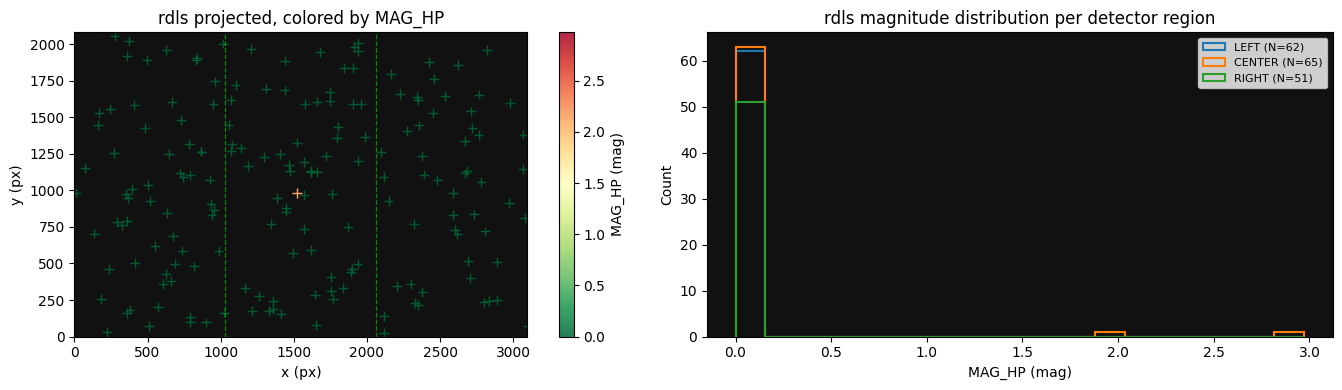

Saved wcs06_rdls_magnitudes.png


In [9]:
if rdls_mag is not None and len(rdls_px) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.set_facecolor('#111')
    sc = ax.scatter(rdls_px, rdls_py, c=rdls_mag, cmap='RdYlGn_r',
                    s=50, alpha=0.85, marker='+', linewidths=1.0)
    plt.colorbar(sc, ax=ax, label=f'{_rdls_mag_col} (mag)')
    for xv in [w/3, 2*w/3]:
        ax.axvline(xv, color='lime', lw=0.9, linestyle='--', alpha=0.5)
    ax.set_xlim(0, w); ax.set_ylim(0, h)
    ax.set_aspect('equal')
    ax.set_title(f'rdls projected, colored by {_rdls_mag_col}')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

    ax = axes[1]
    ax.set_facecolor('#111')
    _mbins = np.linspace(np.nanmin(rdls_mag), np.nanmax(rdls_mag), 20)
    for rname, x0, x1 in regions:
        mask = (rdls_px >= x0) & (rdls_px < x1)
        if mask.sum() > 0:
            ax.hist(rdls_mag[mask], bins=_mbins, histtype='step',
                    linewidth=1.5, label=f'{rname} (N={mask.sum()})')
    ax.set_xlabel(f'{_rdls_mag_col} (mag)')
    ax.set_ylabel('Count')
    ax.set_title('rdls magnitude distribution per detector region')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'wcs06_rdls_magnitudes.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved wcs06_rdls_magnitudes.png')
else:
    print('Magnitude analysis skipped (no rdls magnitude data or no in-frame stars).')

## Interpretation

**What each source set tells you about the right side:**

| Source set | Sparse on right means | Dense on right means |
|---|---|---|
| `axy` | Few sources submitted → extraction or image issue | Detections exist; corr absence is astrometry.net selection |
| `corr` | Fewer matches | Still sparse → astrometry.net chose central matches internally |
| `rdls projected` | Few catalog stars in that sky region | Catalog fine; look for image/WCS issue |
| `image_rd` | Confirms axy sparsity | WCS correctly transforms those positions |

**Key diagnostic ratios (region table):**

- **corr/axy low on right, axy high on right**: `corr.fits` is not representative. Astrometry.net found detections on the right but used fewer for the internal solve. This is expected — use notebook 7 to reconstruct cross-matches across the full detector.

- **axy sparse on right**: Source extraction is missing right-side sources. Check vignetting, spectrum masking artifacts, or background subtraction issues.

- **rdls sparse on right**: Catalog coverage is poor in that sky region.

- **rdls dense but systematically offset from axy positions**: WCS maps the right side incorrectly, evidence of unmodelled field-dependent distortion.

**Next step — Notebook 7:** If `axy` and `rdls_proj` are both present on the right, reconstruct cross-matches using `image-radec.fits` × `rdls.fits` to assess WCS residuals across the full detector.